In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [3]:
data = pd.read_csv("smartcart_customers.csv")

In [4]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [7]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

## 1. Handle missing values

In [8]:
data['Income'] = data['Income'].fillna(data['Income'].median())

In [9]:
data.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
data['Age'] = 2026 - data['Year_Birth']

In [12]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [13]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst = True)

reference_date = data['Dt_Customer'].max()

data['Customer_Tenure_Days'] = (reference_date - data['Dt_Customer']).dt.days

In [14]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [16]:
#Total Spending

data["Total_Spending"] = data[
    [
        'MntWines',
        'MntFruits',
        'MntMeatProducts',
        'MntFishProducts',
        'MntSweetProducts',
        'MntGoldProds']
    ].sum(axis = 1)

In [17]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [18]:
data['Total_Children'] = data[['Kidhome','Teenhome']].sum(axis = 1)

In [19]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [20]:
data = data.drop('ID', axis = 1)

In [21]:
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663,1617,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113,27,2
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312,776,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139,53,1
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161,422,1


In [22]:
data['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [23]:
edu_map = {
    "Basic" : 'Undergraduate', "2n Cycle" : 'Undergraduate',
    "Graduation" : 'Graduate',
    "PhD" : 'Postgraduate', "Master" : 'Postgraduate'
}

In [24]:
data['Education'] = data['Education'].map(edu_map)

In [25]:
data['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [26]:
data['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [27]:
marital_map = {
    "Married" : 'Partner', "Together" : 'Partner', 
    "Single" : 'Alone', "Divorced" : 'Alone', "Widow" : 'Alone', "Alone" : 'Alone', "Absurd" : 'Alone',
    "YOLO" : 'Alone'
}

data['Living_With'] = data['Marital_Status'].map(marital_map)

In [28]:
data['Living_With'].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [29]:
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1617,0,Alone
1,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,27,2,Alone
2,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,776,0,Partner
3,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,53,1,Partner
4,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,422,1,Partner


In [30]:
data_cleaned = data.drop([
    "Year_Birth", "Marital_Status", 'Kidhome', 'Teenhome',
    'Dt_Customer', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
    'MntGoldProds'
], axis = 1)

In [31]:
data_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

In [32]:
data_cleaned.shape

(2240, 15)

In [33]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers


In [34]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

data_cleaned[cols].head()

,Income,Recency,Response,Age,Total_Spending,Total_Children
0,58138.0,58,1,69,1617,0
1,46344.0,38,0,72,27,2
2,71613.0,26,0,61,776,0
3,26646.0,26,0,42,53,1
4,58293.0,94,0,45,422,1


<Figure size 1200x800 with 0 Axes>

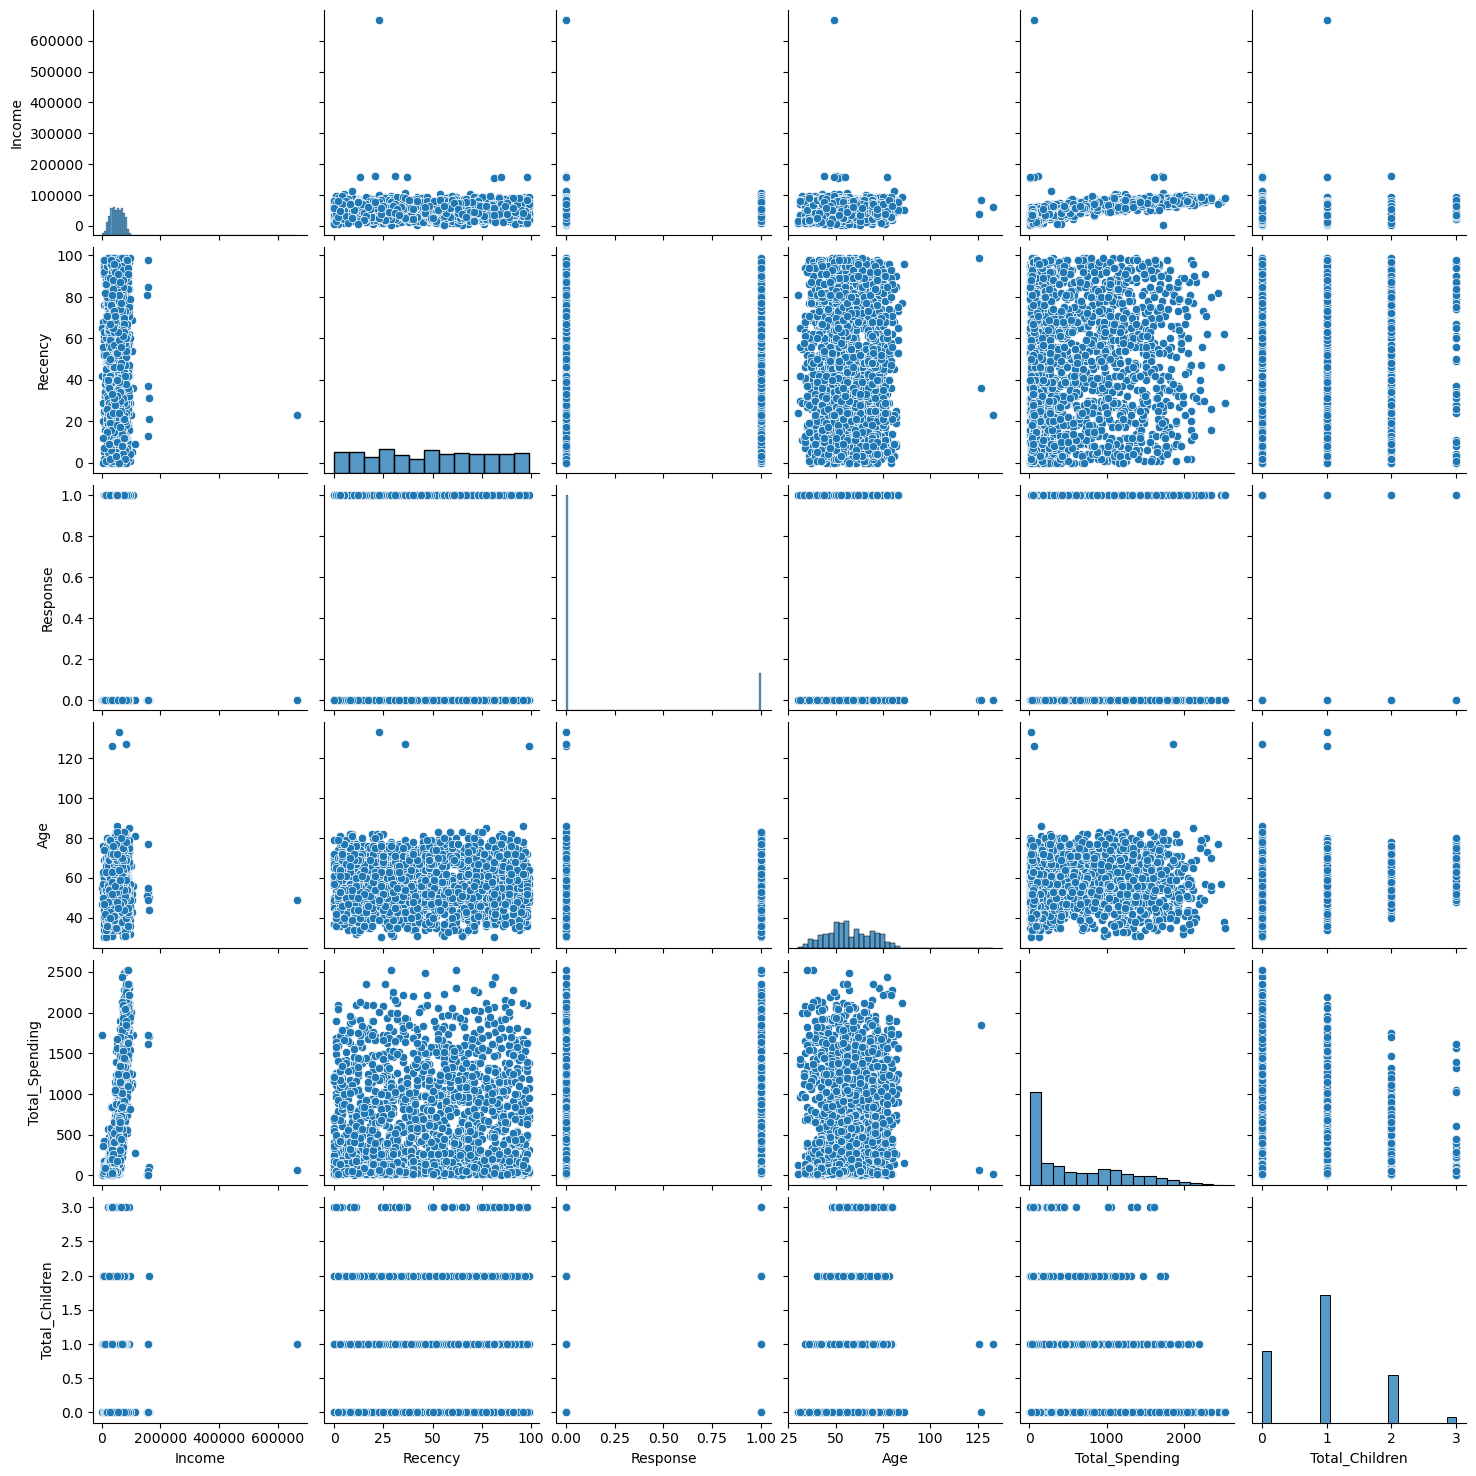

In [35]:
plt.figure(figsize = (12, 8))

sns.pairplot(
    data_cleaned[cols]
)

plt.show()

In [36]:
# Remove outliers

print("Data size with outliers", len(data_cleaned))

data_cleaned = data_cleaned[data_cleaned['Age'] < 90]
data_cleaned = data_cleaned[data_cleaned['Income'] < 600_000]

print("Data size without outliers", len(data_cleaned))

Data size with outliers 2240
Data size without outliers 2236


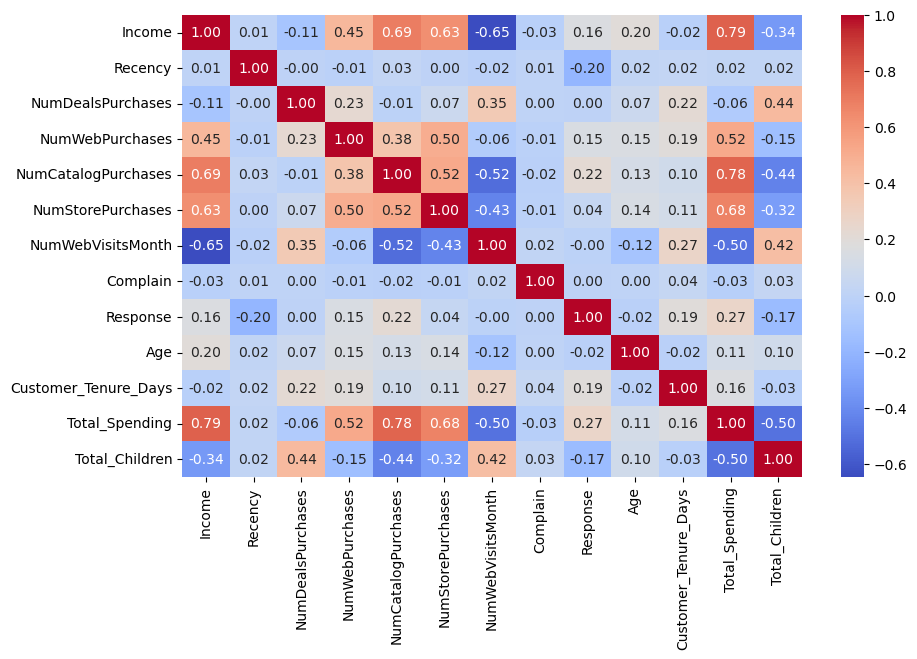

In [37]:
#Heatmap

corr = data_cleaned.corr(numeric_only = True)

plt.figure(figsize = (10, 6))
sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)

plt.show()

## Encoding

In [38]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2236 non-null   object 
 1   Income                2236 non-null   float64
 2   Recency               2236 non-null   int64  
 3   NumDealsPurchases     2236 non-null   int64  
 4   NumWebPurchases       2236 non-null   int64  
 5   NumCatalogPurchases   2236 non-null   int64  
 6   NumStorePurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Complain              2236 non-null   int64  
 9   Response              2236 non-null   int64  
 10  Age                   2236 non-null   int64  
 11  Customer_Tenure_Days  2236 non-null   int64  
 12  Total_Spending        2236 non-null   int64  
 13  Total_Children        2236 non-null   int64  
 14  Living_With           2236 non-null   object 
dtypes: float64(1), int64(12), 

In [39]:
ohe = OneHotEncoder(
    sparse_output = True,
    handle_unknown = 'ignore'
)

cats_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(data_cleaned[cats_cols])

In [40]:
enc_data = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cats_cols), index = data_cleaned.index)

In [41]:
data_encoded = pd.concat([data_cleaned.drop(columns = cats_cols), enc_data], axis = 1)

In [42]:
data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [43]:
X = data_encoded.copy()

In [44]:
#Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
#Visualize

pca = PCA(
    n_components = 3
)

X_pca = pca.fit_transform(X_scaled)

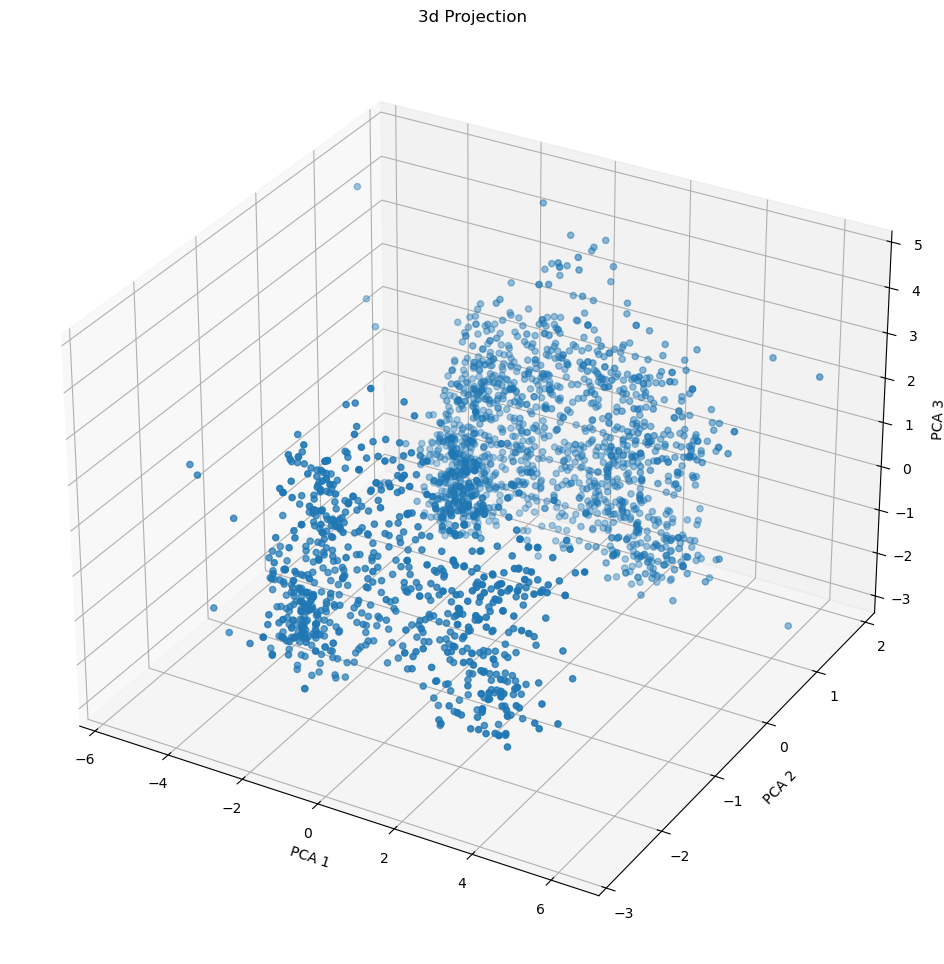

In [46]:
fig = plt.figure(figsize = (12, 12))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2]
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d Projection")
plt.show()

In [47]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## Analyze K value

In [140]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters = k,
        max_iter = 300, 
        random_state = 42
    )
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [141]:
knee = KneeLocator(range(1, 11), wcss, curve = 'convex', direction = 'decreasing')

optimal_k = knee.elbow

In [142]:
optimal_k

np.int64(4)

<Axes: >

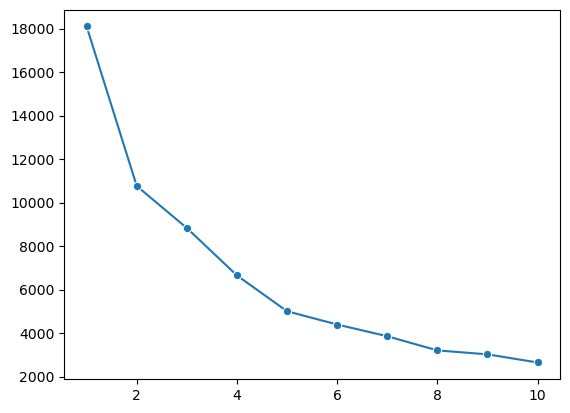

In [143]:
sns.lineplot(
    x = range(1, 11),
    y = wcss,
    marker = 'o'
)

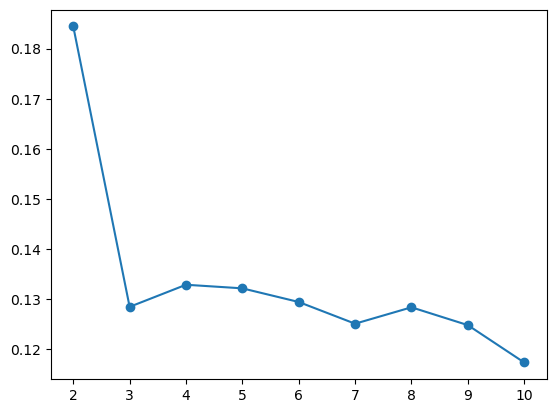

In [144]:
## Silhouete Score
scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker = 'o')

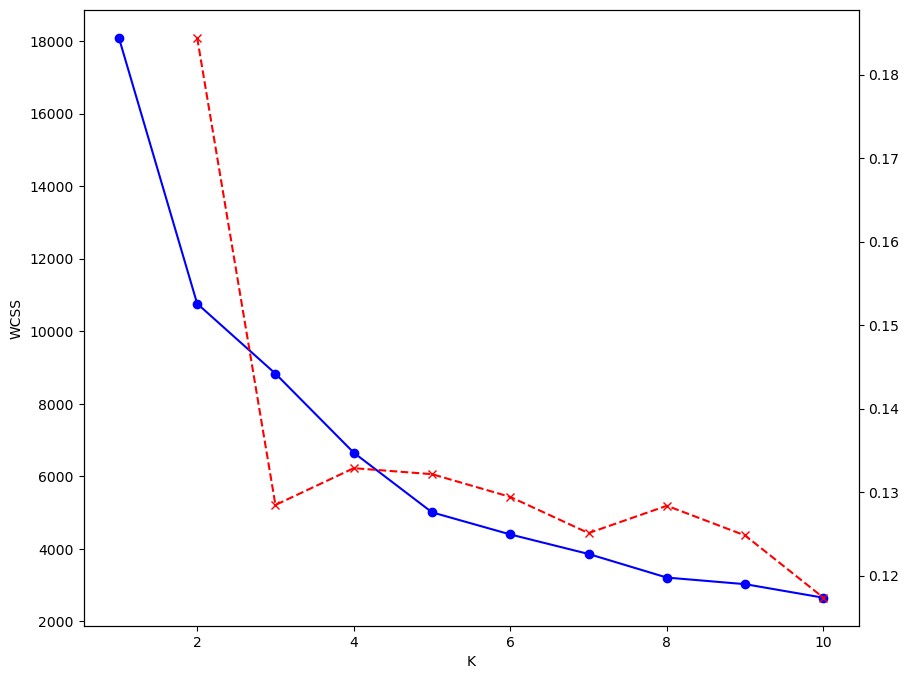

In [145]:
k_range = range(2, 11)

fig, ax = plt.subplots(figsize = (10, 8))

ax.plot(range(1, 11), wcss, marker = 'o', color = 'blue')
ax.set_xlabel("K")
ax.set_ylabel("WCSS")

ax2 = ax.twinx()
ax2.plot(k_range, scores, marker = 'x', color = 'red', linestyle = '--')

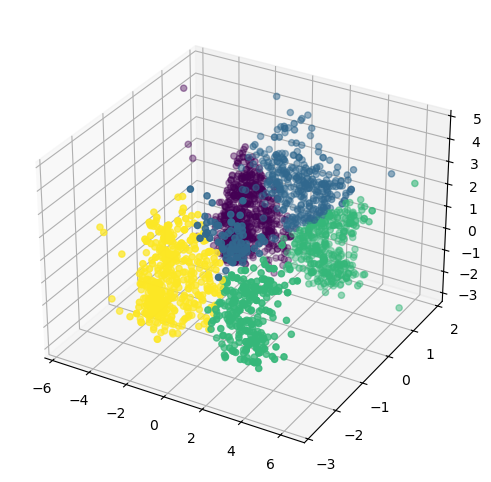

In [146]:
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42
)

labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c = labels
)

plt.show()

In [147]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = 'ward')
labels_agg = agg_clf.fit_predict(X_pca)

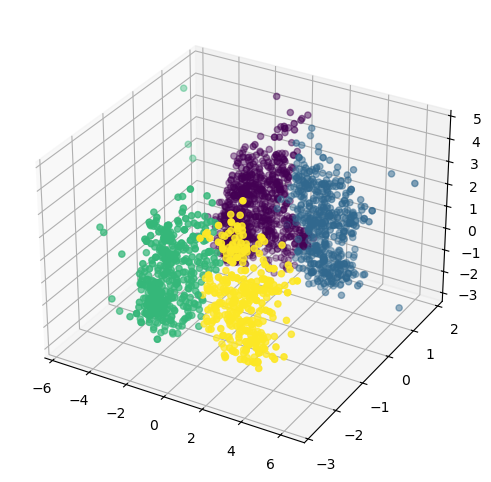

In [148]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c = labels_agg
)

plt.show()

## Characterisation

In [149]:
X['cluster'] = labels_agg

In [150]:
X['cluster'].value_counts()

cluster
0    905
1    534
2    444
3    353
Name: count, dtype: int64

<Axes: xlabel='cluster', ylabel='count'>

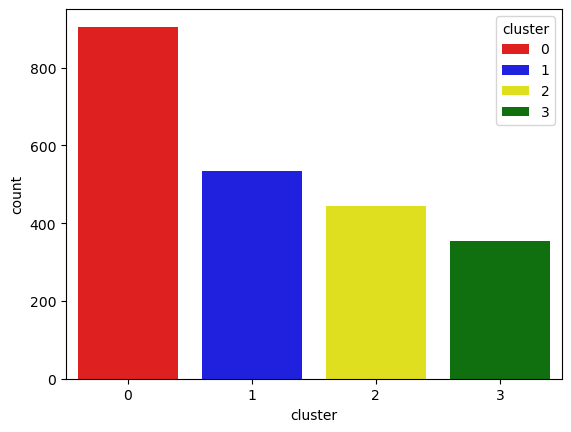

In [151]:
pal = ['red', 'blue', 'yellow', 'green']

sns.countplot(
    x = X['cluster'],
    palette = pal,
    hue = data_cleaned['cluster']
)

<Axes: xlabel='Total_Spending', ylabel='Income'>

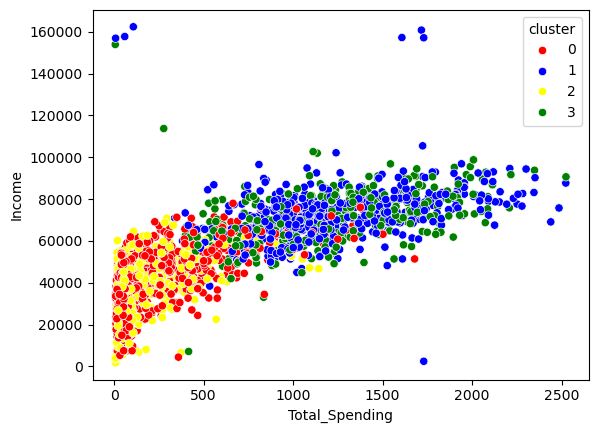

In [152]:
#Income and Spending patterns

sns.scatterplot(
    x = X['Total_Spending'],
    y = X['Income'],
    hue = X['cluster'],
    palette = pal
)

In [153]:
# CLuster summary

cluster_summary = X.groupby('cluster').mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

### Cluster 0 – Moderate-Income Family Customers

* Medium income customers with relatively low total spending.
* Mostly live with a partner and have children.
* Purchase primarily through physical stores, with limited catalog and web purchases.
* Visit the website frequently but convert less into purchases.
* Lowest response rate to marketing campaigns among all clusters.
* Represent traditional, price-conscious family shoppers with moderate engagement.

### Cluster 1 – High-Value Family Customers

* Highest income and highest overall spending segment.
* Mostly live with a partner and have fewer children than Cluster 0.
* Strong buyers across all channels, especially catalog and web purchases.
* Visit the website less frequently but make more purchases when they do.
* Moderate response to marketing campaigns.
* Represent loyal, affluent customers who contribute significantly to revenue.

### Cluster 2 – Low-Spending Independent Customers

* Lowest income and lowest spending segment.
* Predominantly live alone.
* Make few purchases across all channels and show limited engagement.
* High website visit frequency but low conversion into purchases.
* Slightly better campaign response than Cluster 0 despite lower spending.
* Represent budget-conscious or inactive customers with growth potential.

### Cluster 3 – Affluent and Highly Responsive Customers

* High-income customers with very high spending levels.
* Predominantly live alone and have the fewest children.
* Strong purchasing activity across web, catalog, and store channels.
* Lowest website visit frequency, indicating efficient purchase behavior.
* Highest campaign response rate by a large margin.
* Represent the most valuable customer segment and are the most receptive to marketing efforts.

### Overall Conclusion

* Agglomerative Clustering revealed four distinct customer segments.
* Income and spending emerged as the primary differentiating factors.
* Living arrangements further separated customers into family-oriented and independent groups.
* Cluster 3 is the most valuable segment due to its high spending and strong responsiveness to marketing campaigns.
* Cluster 1 represents a stable and affluent customer base that contributes significantly to revenue.
* Clusters 0 and 2 consist of lower-spending customers who frequently browse but purchase less.
* Targeted promotions and personalized marketing strategies can help improve conversion rates among lower-value segments while retaining high-value customers.
